# Week 6 exercises: Supervised Machine Learning

*Complete all exercises in this notebook during week 6 The exercises are not submitted — this is purely for your own learning and for preparing for the assignments, project and exam.*

Note! You should always attempt to complete the tasks first without using AI.

---

## Description of the dataset and goal of the exercise

In this exercise, we will use IBM's Attrition dataset. This is a simulated dataset that contains different information on employees and whether they left the company (Attrition = Yes). 

The goal is to use this dataset to build a model that can predict whether an employee is likely to leave or not.

The dataset consists of the following variables. 

| Variable | Description |
|---|---|
| Age | Age of employee |
| Attrition | Employee attrition status |
| Department | Department of work |
| DistanceFromHome | Distance from home |
| Education | 1-Below College; 2-College; 3-Bachelor; 4-Master; 5-Doctor |
| EducationField | Education field |
| EnvironmentSatisfaction | 1-Low; 2-Medium; 3-High; 4-Very High |
| JobSatisfaction | 1-Low; 2-Medium; 3-High; 4-Very High |
| MaritalStatus | Marital status |
| MonthlyIncome | Monthly income |
| NumCompaniesWorked | Number of companies worked prior to IBM |
| WorkLifeBalance | 1-Bad; 2-Good; 3-Better; 4-Best |
| YearsAtCompany | Current years of service in IBM |

In [1]:
# Importing needed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset

df = pd.read_csv("data/IBM.csv")

df.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   object
 3   DistanceFromHome         1470 non-null   int64 
 4   Education                1470 non-null   int64 
 5   EducationField           1470 non-null   object
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobSatisfaction          1470 non-null   int64 
 8   MaritalStatus            1470 non-null   object
 9   MonthlyIncome            1470 non-null   int64 
 10  NumCompaniesWorked       1470 non-null   int64 
 11  WorkLifeBalance          1470 non-null   int64 
 12  YearsAtCompany           1470 non-null   int64 
dtypes: int64(9), object(4)
memory usage: 149.4+ KB


In [4]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

## Part 1: Preprocessing

### Exercise 1: 

The dataset needs preprocessing before it is ready for use. 

a) Apply one-hot encoding to the variable MaritalStatus.

b) Apply label encoding to EducationField and Department.

c) Apply standardization to Age and MonthlyIncome, and scale DistanceFromHome to 0-1.

d) Encode Attrition also numerically (1 = yes, 0 = No).


In [5]:
# a) One-hot encoding for MaritalStatust
df = pd.get_dummies(df, columns=["MaritalStatus"], drop_first=True, dtype=float)
df.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany,MaritalStatus_Married,MaritalStatus_Single
0,41,Yes,Sales,1,2,Life Sciences,2,4,5993,8,1,6,0.0,1.0
1,49,No,Research & Development,8,1,Life Sciences,3,2,5130,1,3,10,1.0,0.0
2,37,Yes,Research & Development,2,2,Other,4,3,2090,6,3,0,0.0,1.0
3,33,No,Research & Development,3,4,Life Sciences,4,3,2909,1,3,8,1.0,0.0
4,27,No,Research & Development,2,1,Medical,1,2,3468,9,3,2,1.0,0.0


In [6]:
# b) Label encoding for EducationField and Department
from sklearn.preprocessing import LabelEncoder

le_edu = LabelEncoder()
le_dept = LabelEncoder()

df["EducationField"] = le_edu.fit_transform(df["EducationField"])
df["Department"] = le_dept.fit_transform(df["Department"])

df.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany,MaritalStatus_Married,MaritalStatus_Single
0,41,Yes,2,1,2,1,2,4,5993,8,1,6,0.0,1.0
1,49,No,1,8,1,1,3,2,5130,1,3,10,1.0,0.0
2,37,Yes,1,2,2,4,4,3,2090,6,3,0,0.0,1.0
3,33,No,1,3,4,1,4,3,2909,1,3,8,1.0,0.0
4,27,No,1,2,1,3,1,2,3468,9,3,2,1.0,0.0


In [7]:
# c) Standardization for Age and MonthlyIncome, MinMax scaling for DistanceFromHome
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_standard = StandardScaler()
df[["Age", "MonthlyIncome"]] = scaler_standard.fit_transform(df[["Age", "MonthlyIncome"]])

scaler_minmax = MinMaxScaler()
df[["DistanceFromHome"]] = scaler_minmax.fit_transform(df[["DistanceFromHome"]])

df.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany,MaritalStatus_Married,MaritalStatus_Single
0,0.446350,Yes,2,0.000000,2,1,2,4,-0.108350,8,1,6,0.0,1.0
1,1.322365,No,1,0.250000,1,1,3,2,-0.291719,1,3,10,1.0,0.0
2,0.008343,Yes,1,0.035714,2,4,4,3,-0.937654,6,3,0,0.0,1.0
3,-0.429664,No,1,0.071429,4,1,4,3,-0.763634,1,3,8,1.0,0.0
4,-1.086676,No,1,0.035714,1,3,1,2,-0.644858,9,3,2,1.0,0.0


In [8]:
# d) Encode Attrition also numerically (1 = yes, 0 = No).

df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

## Part 2: Training

### Exercise 2: Train test split 

a) Train-test split: Use sklearn.model_selection.train_test_split to split preprocessed features and encoded target into training and test sets (80/20). Set random_state for reproducibility. It is good idea to also check the class balance using value_counts().

b) Train-validation-test split: Use train_test_split twice. First 80/20 to get a train and test set, then split the 80 into 75/25 to get a train and validation set, resulting in a 60/20/20 overall split.



In [9]:
# a) Train-test split (80/20)
from sklearn.model_selection import train_test_split

# Encode target variable
df["Attrition"] = df["Attrition"]

X = df.drop(columns=["Attrition"])
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())
print("\nClass balance (test):")
print(y_test.value_counts())

Train set size: 1176
Test set size: 294

Class balance (train):
Attrition
0    978
1    198
Name: count, dtype: int64

Class balance (test):
Attrition
0    255
1     39
Name: count, dtype: int64


In [10]:
# b) Train-validation-test split (60/20/20)
# First split: 80/20 into train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: 75/25 of the 80% into train and validation (0.75 * 0.8 = 0.6, 0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("Train set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())

Train set size: 882
Validation set size: 294
Test set size: 294

Class balance (train):
Attrition
0    734
1    148
Name: count, dtype: int64


### Exercise 3: Training models and making predictions

From the previous part, **use the train-validation-test split**. Thus, for training and making the predictions at this point, use the train set and validation set. We will train two different classifiers using different algorithms.

Set Attrition as y, and all other columns as features X.

a) Train an SVM model and make predictions on the validation set. Set class_weight="balanced" as the dataset is inbalanced.

b) Train a random forest model and make predictions on the validation set

In [11]:
# a) Train an SVM model and predict on validation set
from sklearn.svm import SVC

svm_model = SVC(random_state=42, class_weight="balanced")
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_val)

In [12]:
# b) Train a Random Forest model and predict on validation set
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

## Part 3: Initial evaluation

### Exercise 4: Evaluating with different metrics

a) Report the accuracy, precision, recall and F1-score of the models. Think which one(s) of these performance metrics make most sense to prioritize given the dataset and goal of the model.

b) Generate and print a confusion matrix for both models

In [13]:
# a) Accuracy, Precision, Recall, F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, y_pred in [("SVM", y_pred_svm), ("Random Forest", y_pred_rf)]:
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred):.4f}")
    print()

# Note: Given the class imbalance (more "No" than "Yes"), accuracy alone can be misleading.
# Recall is important here because we want to identify employees likely to leave (Attrition=Yes).
# A model with high accuracy but low recall would miss most at-risk employees.
# F1-score provides a balanced view of precision and recall.

--- SVM ---
Accuracy:  0.7109
Precision: 0.3267
Recall:    0.6600
F1-score:  0.4371

--- Random Forest ---
Accuracy:  0.8401
Precision: 0.6364
Recall:    0.1400
F1-score:  0.2295



SVM Confusion Matrix:
[[176  68]
 [ 17  33]]

Random Forest Confusion Matrix:
[[240   4]
 [ 43   7]]



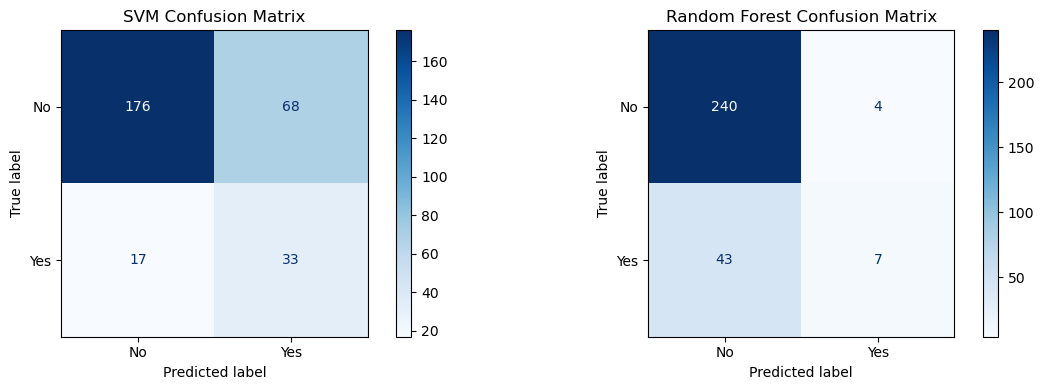

In [14]:
# b) Confusion matrices

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# The code below produces the confusion matrix as a simple numpy array.

for name, y_pred in [("SVM", y_pred_svm), ("Random Forest", y_pred_rf)]:
    cm = confusion_matrix(y_val, y_pred)
    print(f"{name} Confusion Matrix:")
    print(cm)
    print()

# The code below produces a nicer confusion matrix with colors.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, y_pred in zip(axes, ["SVM", "Random Forest"], [y_pred_svm, y_pred_rf]):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues")
    ax.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

## Part 4: Making the models better

Now that we have tested very roughly that the models work and we have some experience with the basic methods, we can start thinking of how to make the model better.

### Exercise 5: Hyperparameter tuning

a) Use gridsearch to test different hyperparameter values for C and gamma on the SVM model. Remember to use the training and validation set still at this point.

b) Use gridsearch to test different values for some of the hyperparameters of random forest. E.g. try providing 2-3 different values for n_estimators, max_depth, bootstrap. Remember to use the training and validation set still at this point.

In [15]:
# a) GridSearch for SVM hyperparameters
from sklearn.model_selection import GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "kernel": ["rbf"]
}
grid_svm = GridSearchCV(SVC(random_state=42, class_weight="balanced"), param_grid_svm, cv=5, scoring="recall", n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best SVM parameters:", grid_svm.best_params_)
print("Best SVM Recall (CV):", f"{grid_svm.best_score_:.4f}")
# Evaluate on validation set
y_pred_svm_tuned = grid_svm.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_svm_tuned):.4f}")

Best SVM parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM Recall (CV): 0.6549
Validation Recall: 0.7000


In [16]:
# b) GridSearch for Random Forest hyperparameters
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "bootstrap": [True, False]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring="recall", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best RF Recall (CV):", f"{grid_rf.best_score_:.4f}")

# Evaluate on validation set
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_rf_tuned):.4f}")

Best RF parameters: {'bootstrap': False, 'max_depth': None, 'n_estimators': 100}
Best RF Recall (CV): 0.1547
Validation Recall: 0.1600


### Exercise 6: Evaluating the final model

a) Select the best parameters from 5a and now test the SVM model on test set instead of the validation to get a final score.

a) Select the best parameters from 5b and now test the random forest model on test set instead of the validation to get a final score.


In [17]:
# a) Final SVM evaluation on test set
y_pred_svm_final = grid_svm.best_estimator_.predict(X_test)

print("--- Final SVM (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_final):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm_final):.4f}")

--- Final SVM (Test Set) ---
Accuracy:  0.6429
Precision: 0.1944
Recall:    0.5385
F1-score:  0.2857


In [18]:
# b) Final Random Forest evaluation on test set
y_pred_rf_final = grid_rf.best_estimator_.predict(X_test)

print("--- Final Random Forest (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_final):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf_final):.4f}")

--- Final Random Forest (Test Set) ---
Accuracy:  0.8741
Precision: 0.5833
Recall:    0.1795
F1-score:  0.2745
